
# 04 — Modeling Healthcare Accessibility in Casablanca

This notebook develops interpretable machine learning models to explain and predict facility-level healthcare accessibility in Casablanca.

**Objectives**
- Predict accessibility outcomes (default target: `accessibility_score`)
- Identify key drivers of accessibility inequality
- Simulate practical interventions (transport, healthcare supply, and network efficiency)


## 0. Setup

In [3]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42


def resolve_project_root(start: Path) -> Path:
    start = start.resolve()
    for c in [start, *start.parents]:
        if (c / 'data').exists() and (c / 'notebooks').exists():
            return c
    return start


PROJECT_ROOT = resolve_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
ANALYSIS_DIR = DATA_DIR / 'analysis'

print('Project root:', PROJECT_ROOT)


Project root: D:\Capstone\capstone_repo


## 1. Data Preparation and Spatial Feature Engineering

This section builds a **facility-level modeling dataset** (one row per hospital), merges accessibility outcomes, and engineers additional spatial features to better capture urban structure and network effects.


In [4]:
def first_existing_path(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None


def load_geo_or_csv(path: Path):
    if path.suffix.lower() in {'.gpkg', '.shp', '.geojson'}:
        return gpd.read_file(path)
    df = pd.read_csv(path)
    if 'geometry' in df.columns:
        try:
            return gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df['geometry']), crs='EPSG:4326')
        except Exception:
            pass
    lon = next((c for c in ['longitude', 'lon', 'x'] if c in df.columns), None)
    lat = next((c for c in ['latitude', 'lat', 'y'] if c in df.columns), None)
    if lon and lat:
        return gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df[lon], df[lat]), crs='EPSG:4326')
    return gpd.GeoDataFrame(df.copy())


def standardize_name(s):
    return s.astype(str).str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)


def count_within_radius(points_gdf, query_geom, radius_m):
    return int((points_gdf.distance(query_geom) <= radius_m).sum())


def sum_edges_within_radius(edges_gdf, query_geom, radius_m, length_col='length'):
    mask = edges_gdf.distance(query_geom) <= radius_m
    if length_col in edges_gdf.columns:
        return float(edges_gdf.loc[mask, length_col].fillna(0).sum())
    return float(mask.sum())


stops_path = first_existing_path([
    PROCESSED_DIR / 'Casablanca_Transport_Stops.gpkg',
    PROCESSED_DIR / 'Casablanca_Transport_Stops.csv',
    RAW_DIR / 'casablanca_transport_stops.csv'
])
health_path = first_existing_path([
    PROCESSED_DIR / 'Casablanca_Healthcare.gpkg',
    PROCESSED_DIR / 'Casablanca_Healthcare.csv',
    RAW_DIR / 'casablanca_healthcare.csv'
])
access_path = first_existing_path([
    ANALYSIS_DIR / 'healthcare_accessibility_results.gpkg',
    ANALYSIS_DIR / 'healthcare_accessibility_results.csv',
    PROCESSED_DIR / 'hospitals_enriched.csv'
])
nodes_path = first_existing_path([RAW_DIR / 'nodes.shp'])
edges_path = first_existing_path([RAW_DIR / 'edges.shp'])

print('stops:', stops_path)
print('health:', health_path)
print('access:', access_path)
print('nodes:', nodes_path)
print('edges:', edges_path)

if not all([stops_path, health_path, nodes_path, edges_path]):
    raise FileNotFoundError('Missing required datasets (stops/health/nodes/edges).')

stops = load_geo_or_csv(stops_path)
health = load_geo_or_csv(health_path)
access = load_geo_or_csv(access_path) if access_path else health.copy()
nodes = gpd.read_file(nodes_path)
edges = gpd.read_file(edges_path)

CRS_METRIC = 'EPSG:32629'
for name, gdf in [('stops', stops), ('health', health), ('access', access), ('nodes', nodes), ('edges', edges)]:
    if 'geometry' not in gdf.columns or gdf.geometry.isna().all():
        raise ValueError(f'{name} layer must have valid geometry')

stops = stops.to_crs(CRS_METRIC)
health = health.to_crs(CRS_METRIC)
access = access.to_crs(CRS_METRIC)
nodes = nodes.to_crs(CRS_METRIC)
edges = edges.to_crs(CRS_METRIC)

# Build facility-level base table
DISTRICT_COL = 'facility'
model_df = health.copy().reset_index(drop=True)
if 'name' not in model_df.columns:
    model_df['name'] = [f'facility_{i}' for i in range(len(model_df))]
model_df[DISTRICT_COL] = model_df['name'].astype(str).str.strip()
model_df['facility_name_key'] = standardize_name(model_df[DISTRICT_COL])

# Merge target columns when available
if 'name' in access.columns:
    acc = access.copy()
    acc['facility_name_key'] = standardize_name(acc['name'])
    target_cols = [c for c in ['accessibility_score', 'total_travel_time_min'] if c in acc.columns]
    merge_cols = ['facility_name_key'] + target_cols
    model_df = model_df.merge(acc[merge_cols].drop_duplicates('facility_name_key'), on='facility_name_key', how='left')

# Core transport/health/network features
model_df['distance_to_nearest_stop_m'] = model_df.geometry.apply(lambda g: float(stops.distance(g).min()))
model_df['num_stops_500m'] = model_df.geometry.apply(lambda g: count_within_radius(stops, g, 500))
model_df['num_stops_1000m'] = model_df.geometry.apply(lambda g: count_within_radius(stops, g, 1000))
model_df['stop_density'] = model_df['num_stops_500m']

model_df['num_healthcare_facilities'] = model_df.geometry.apply(
    lambda g: int(((health.distance(g) <= 1000) & (health.distance(g) > 1)).sum())
)
model_df['healthcare_density_1km'] = model_df['num_healthcare_facilities'] / (np.pi * 1.0**2)
model_df['stop_density_1km'] = model_df['num_stops_1000m'] / (np.pi * 1.0**2)

model_df['distance_to_nearest_node_m'] = model_df.geometry.apply(lambda g: float(nodes.distance(g).min()))
model_df['local_edge_count_500m'] = model_df.geometry.apply(lambda g: int((edges.distance(g) <= 500).sum()))
model_df['local_edge_length_500m'] = model_df.geometry.apply(lambda g: sum_edges_within_radius(edges, g, 500))

# Network centrality proxy from nearest node degree
edge_degree = pd.concat([edges['u'], edges['v']], axis=0).value_counts()
node_degree_map = edge_degree.to_dict()
if 'osmid' in nodes.columns:
    nodes['node_degree'] = nodes['osmid'].map(node_degree_map).fillna(0)
else:
    nodes['node_degree'] = 0

node_sindex = nodes.sindex

def nearest_node_degree(query_geom):
    nearest_idx = list(node_sindex.nearest(query_geom, return_all=False))[1][0]
    return float(nodes.iloc[nearest_idx]['node_degree'])

model_df['nearest_node_degree'] = model_df.geometry.apply(nearest_node_degree)

# Urban structure features
centroids = model_df.geometry.centroid
city_center = centroids.unary_union.centroid
model_df['distance_to_city_center_km'] = centroids.distance(city_center) / 1000
model_df['urban_ring'] = pd.qcut(
    model_df['distance_to_city_center_km'].rank(method='first'),
    q=3,
    labels=['Inner', 'Middle', 'Outer']
)
model_df['zone_type'] = model_df['urban_ring']

# Neighbor accessibility context (k-nearest hospitals)
if 'accessibility_score' in model_df.columns:
    k_neighbors = min(5, max(2, len(model_df) - 1))
    coords = np.column_stack([centroids.x.values, centroids.y.values])
    dist_mat = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
    np.fill_diagonal(dist_mat, np.inf)
    nn_idx = np.argsort(dist_mat, axis=1)[:, :k_neighbors]
    neigh_mean = []
    values = model_df['accessibility_score'].values
    for i in range(len(model_df)):
        neigh_vals = values[nn_idx[i]]
        neigh_mean.append(float(np.nanmean(neigh_vals)))
    model_df['neighbor_accessibility_mean'] = neigh_mean
else:
    model_df['neighbor_accessibility_mean'] = np.nan

# Legacy placeholders kept for backward compatibility with prior notebook text
model_df['built_up_area'] = model_df['local_edge_length_500m']
model_df['population'] = model_df['local_edge_count_500m']
model_df['population_density'] = model_df['local_edge_count_500m']

# Required interaction terms
model_df['interaction_stop_pop_density'] = model_df['stop_density'] * model_df['population_density']
model_df['interaction_fac_pop'] = model_df['num_healthcare_facilities'] * model_df['population']
model_df['interaction_built_stop'] = model_df['built_up_area'] * model_df['stop_density']

TARGET_COL = 'accessibility_score' if 'accessibility_score' in model_df.columns else 'total_travel_time_min'
if TARGET_COL not in model_df.columns:
    raise ValueError('Target not found: expected accessibility_score or total_travel_time_min')

FEATURE_COLS = [
    'population',
    'population_density',
    'built_up_area',
    'stop_density',
    'num_healthcare_facilities',
    'distance_to_nearest_stop_m',
    'distance_to_nearest_node_m',
    'local_edge_count_500m',
    'distance_to_city_center_km',
    'healthcare_density_1km',
    'stop_density_1km',
    'nearest_node_degree',
    'neighbor_accessibility_mean',
    'interaction_stop_pop_density',
    'interaction_fac_pop',
    'interaction_built_stop'
]

model_df = model_df[[DISTRICT_COL, 'geometry', 'urban_ring', 'zone_type'] + FEATURE_COLS + [TARGET_COL]].copy()

rows_before = len(model_df)
model_df = model_df.dropna(subset=[TARGET_COL]).copy()
rows_after = len(model_df)

print(f'Dropped {rows_before - rows_after} rows with missing target values in {TARGET_COL}.')
print('Modeling rows (facilities):', len(model_df))
print(model_df[FEATURE_COLS + [TARGET_COL]].isna().sum().sort_values(ascending=False).head(10))


stops: D:\Capstone\capstone_repo\data\processed\Casablanca_Transport_Stops.gpkg
health: D:\Capstone\capstone_repo\data\processed\Casablanca_Healthcare.gpkg
access: D:\Capstone\capstone_repo\data\analysis\healthcare_accessibility_results.gpkg
nodes: D:\Capstone\capstone_repo\data\raw\nodes.shp
edges: D:\Capstone\capstone_repo\data\raw\edges.shp
Dropped 12 rows with missing target values in accessibility_score.
Modeling rows (facilities): 72
population                    0
population_density            0
built_up_area                 0
stop_density                  0
num_healthcare_facilities     0
distance_to_nearest_stop_m    0
distance_to_nearest_node_m    0
local_edge_count_500m         0
accessibility_score           0
dtype: int64


## 2. Exploratory Data Analysis (EDA)

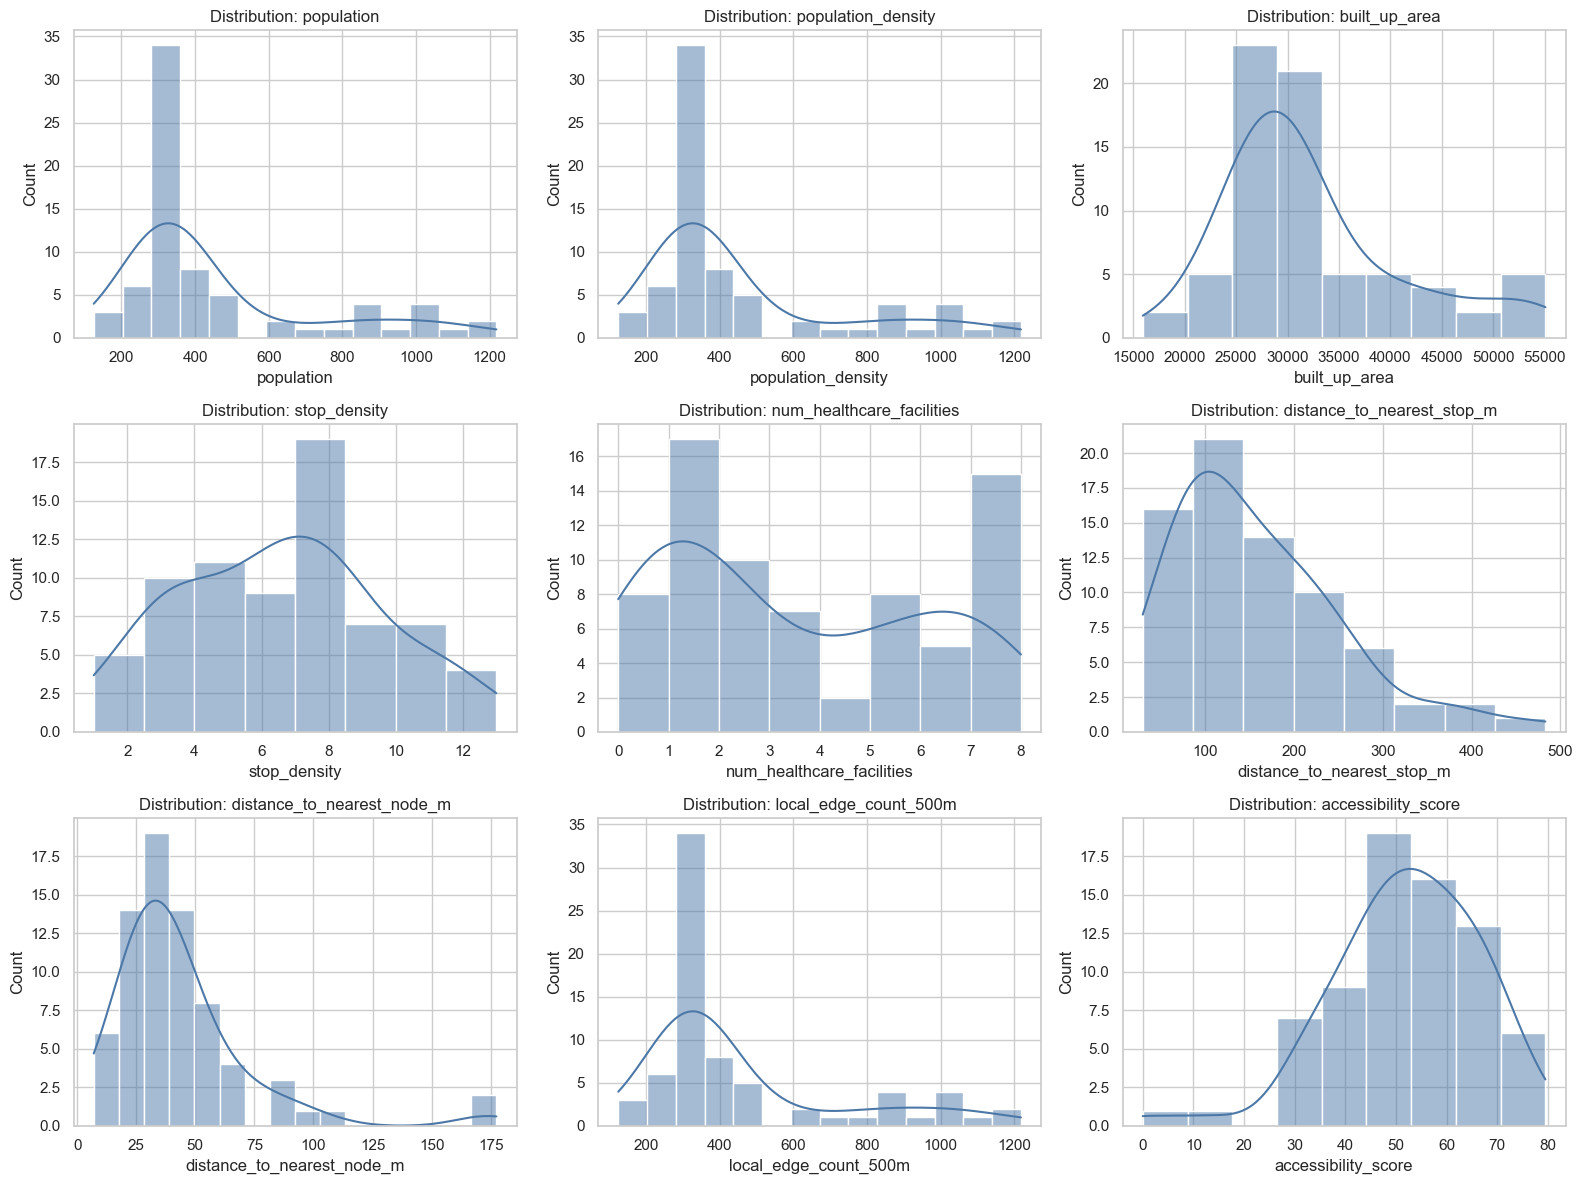

In [5]:

eda_cols = FEATURE_COLS + [TARGET_COL]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, c in enumerate(eda_cols):
    sns.histplot(model_df[c], kde=True, ax=axes[i], color='#4C78A8')
    axes[i].set_title(f'Distribution: {c}')
for j in range(len(eda_cols), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


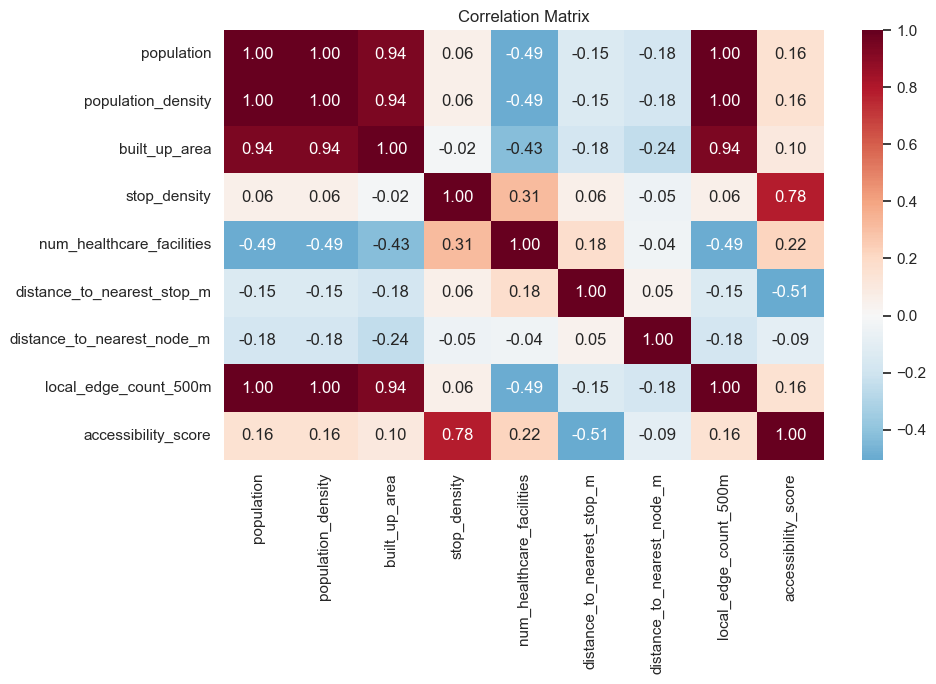

In [6]:

plt.figure(figsize=(10, 7))
corr = model_df[FEATURE_COLS + [TARGET_COL]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


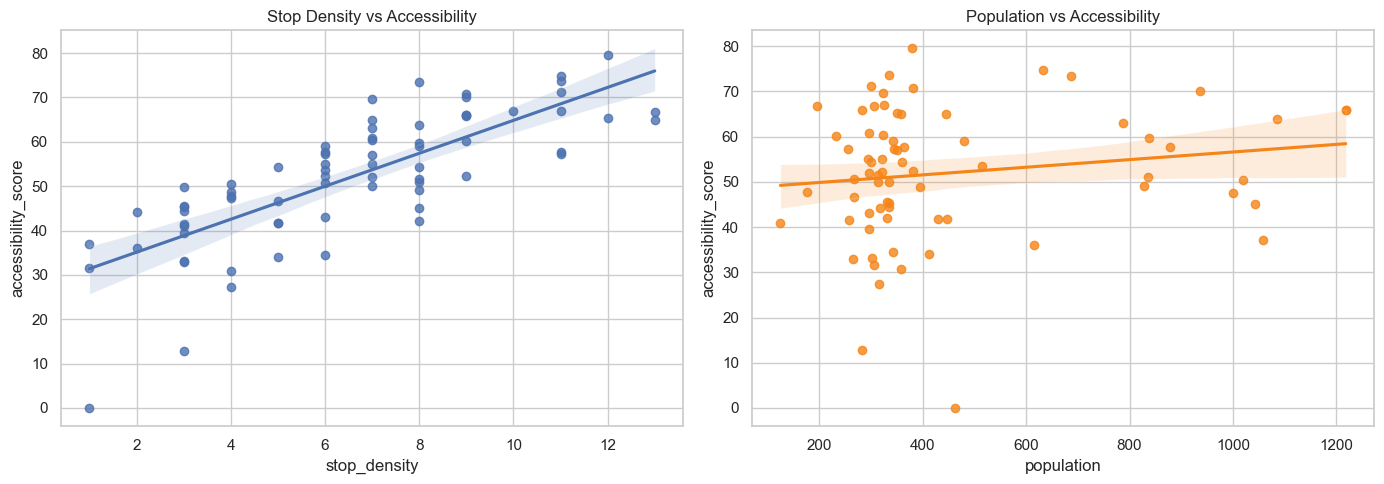

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.regplot(data=model_df, x='stop_density', y=TARGET_COL, ax=axes[0], scatter_kws={'alpha': 0.8})
axes[0].set_title('Stop Density vs Accessibility')
sns.regplot(data=model_df, x='population', y=TARGET_COL, ax=axes[1], color='#F58518', scatter_kws={'alpha': 0.8})
axes[1].set_title('Population vs Accessibility')
plt.tight_layout()
plt.show()


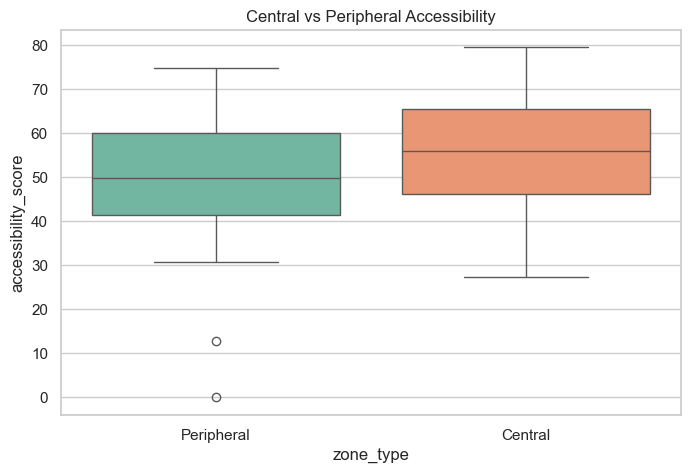

,count,mean,std,min,25%,50%,75%,max
zone_type,,,,,,,,
Central,36.0,55.142728,12.46011,27.366979,46.122617,56.042246,65.434551,79.506231
Peripheral,36.0,48.940536,15.73246,0.000000,41.346854,49.753362,59.965638,74.771252


In [8]:

centroids = model_df.geometry.centroid
city_center = centroids.unary_union.centroid
model_df['distance_to_city_center_km'] = centroids.distance(city_center) / 1000
model_df['zone_type'] = np.where(model_df['distance_to_city_center_km'] <= model_df['distance_to_city_center_km'].median(), 'Central', 'Peripheral')

plt.figure(figsize=(8,5))
sns.boxplot(data=model_df, x='zone_type', y=TARGET_COL, palette='Set2')
plt.title('Central vs Peripheral Accessibility')
plt.show()

display(model_df.groupby('zone_type')[TARGET_COL].describe())


## 3. Rigorous Modeling Pipeline and Evaluation

We use reproducible train/test split and cross-validation with consistent preprocessing. This supports robust model comparison and overfitting checks.


In [9]:
X = model_df[FEATURE_COLS].copy()
y = model_df[TARGET_COL].copy()

valid_mask = y.notna()
X = X.loc[valid_mask].copy()
y = y.loc[valid_mask].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_features = FEATURE_COLS.copy()


def build_pipeline(estimator, scale_numeric=False):
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
    ]
    if scale_numeric:
        steps.append(('scaler', StandardScaler()))

    preprocessor = ColumnTransformer(
        transformers=[('num', Pipeline(steps=steps), numeric_features)],
        remainder='drop'
    )

    return Pipeline([
        ('preprocess', preprocessor),
        ('model', estimator)
    ])


models = {
    'LinearRegression': build_pipeline(LinearRegression(), scale_numeric=True),
    'RandomForest': build_pipeline(
        RandomForestRegressor(n_estimators=400, min_samples_leaf=2, random_state=RANDOM_STATE),
        scale_numeric=False
    ),
    'GradientBoosting': build_pipeline(
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        scale_numeric=False
    )
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

results = []
fitted_models = {}
train_test_predictions = {}

for name, pipe in models.items():
    cv_out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=None)
    pipe.fit(X_train, y_train)

    y_pred_train = pipe.predict(X_train)
    y_pred_test = pipe.predict(X_test)

    results.append({
        'model': name,
        'cv_rmse_mean': -cv_out['test_rmse'].mean(),
        'cv_rmse_std': cv_out['test_rmse'].std(),
        'cv_mae_mean': -cv_out['test_mae'].mean(),
        'cv_mae_std': cv_out['test_mae'].std(),
        'cv_r2_mean': cv_out['test_r2'].mean(),
        'cv_r2_std': cv_out['test_r2'].std(),
        'train_rmse': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'train_mae': mean_absolute_error(y_train, y_pred_train),
        'test_mae': mean_absolute_error(y_test, y_pred_test),
        'train_r2': r2_score(y_train, y_pred_train),
        'test_r2': r2_score(y_test, y_pred_test),
        'overfit_gap_r2': r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test)
    })

    fitted_models[name] = pipe
    train_test_predictions[name] = {
        'train_pred': y_pred_train,
        'test_pred': y_pred_test
    }

results_df = pd.DataFrame(results).sort_values('cv_rmse_mean')
display(results_df)

best_model_name = results_df.iloc[0]['model']
best_model = fitted_models[best_model_name]
print(f'Best model selected by CV RMSE: {best_model_name}')


,model,RMSE,MAE,R2
0,LinearRegression,2.829851,2.459163,0.933018
1,RandomForest,4.030393,3.239775,0.864128
2,GradientBoosting,4.911945,3.825112,0.798191


Best model: LinearRegression


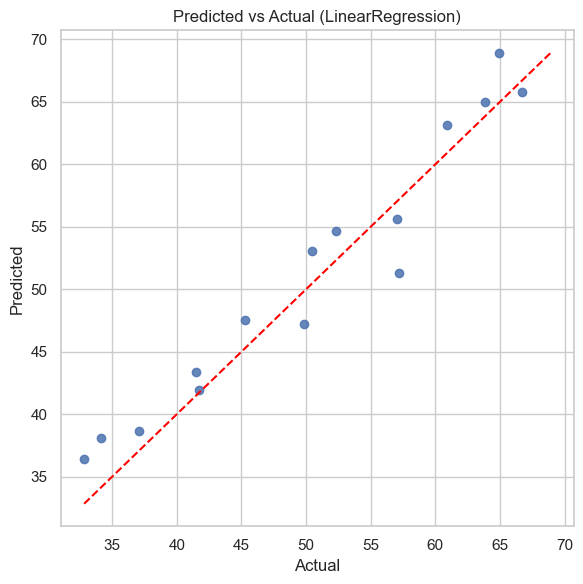

In [10]:
y_pred_best_train = train_test_predictions[best_model_name]['train_pred']
y_pred_best_test = train_test_predictions[best_model_name]['test_pred']

residuals = y_test - y_pred_best_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_pred_best_test, alpha=0.8)
mn, mx = min(y_test.min(), y_pred_best_test.min()), max(y_test.max(), y_pred_best_test.max())
axes[0].plot([mn, mx], [mn, mx], '--', color='red')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Predicted vs Actual ({best_model_name})')

sns.histplot(residuals, kde=True, ax=axes[1], color='#4C78A8')
axes[1].set_title('Error Distribution (Residuals)')
axes[1].set_xlabel('Actual - Predicted')

axes[2].scatter(y_pred_best_test, residuals, alpha=0.8, color='#F58518')
axes[2].axhline(0, linestyle='--', color='black')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted')

plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
print('Concise evaluation summary:')
print(f"- CV RMSE: {best_row['cv_rmse_mean']:.3f} +/- {best_row['cv_rmse_std']:.3f}")
print(f"- CV MAE: {best_row['cv_mae_mean']:.3f} +/- {best_row['cv_mae_std']:.3f}")
print(f"- CV R2: {best_row['cv_r2_mean']:.3f} +/- {best_row['cv_r2_std']:.3f}")
print(f"- Test RMSE: {best_row['test_rmse']:.3f} | Test R2: {best_row['test_r2']:.3f}")
if best_row['overfit_gap_r2'] > 0.10:
    print('- Potential overfitting detected: train-test R2 gap is high.')
else:
    print('- No major overfitting signal from train-test R2 gap.')


## 4. Model Interpretation and Driver Analysis

We interpret the selected model with a policy focus on transport versus healthcare supply drivers.


,feature,importance
3,stop_density,10.329896
5,distance_to_nearest_stop_m,8.356829
2,built_up_area,1.763897
4,num_healthcare_facilities,1.707197
1,population_density,0.959642
7,local_edge_count_500m,0.959642
0,population,0.959642
6,distance_to_nearest_node_m,0.461453


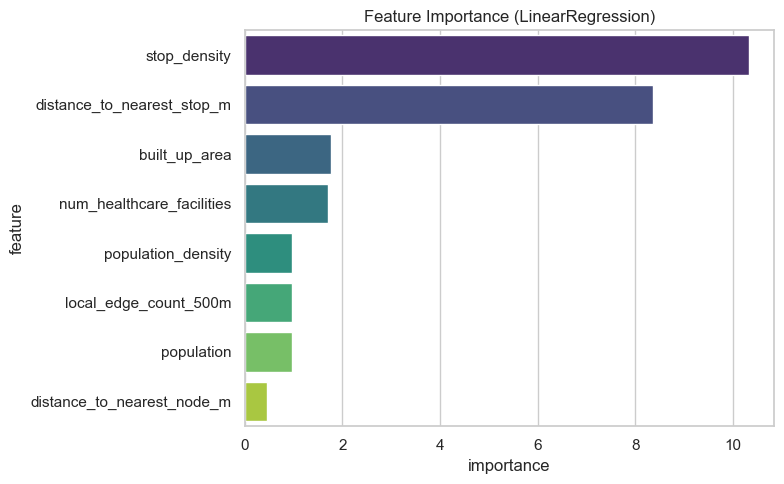

In [11]:
transport_features = [
    'stop_density',
    'distance_to_nearest_stop_m',
    'distance_to_nearest_node_m',
    'stop_density_1km',
    'nearest_node_degree'
]
healthcare_supply_features = [
    'num_healthcare_facilities',
    'healthcare_density_1km'
]

if best_model_name == 'LinearRegression':
    coefs = best_model.named_steps['model'].coef_
    coef_df = pd.DataFrame({
        'feature': FEATURE_COLS,
        'coefficient': coefs,
        'abs_coefficient': np.abs(coefs)
    }).sort_values('abs_coefficient', ascending=False)

    coef_df['driver_group'] = np.where(
        coef_df['feature'].isin(transport_features),
        'Transport',
        np.where(coef_df['feature'].isin(healthcare_supply_features), 'HealthcareSupply', 'Other')
    )

    print('Linear model coefficients (standardized scale):')
    display(coef_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=coef_df.head(12), x='coefficient', y='feature', hue='driver_group', dodge=False)
    plt.axvline(0, linestyle='--', color='black')
    plt.title('Top standardized coefficients (Linear Regression)')
    plt.tight_layout()
    plt.show()

    feature_importance_df = coef_df[['feature', 'abs_coefficient', 'driver_group']].rename(
        columns={'abs_coefficient': 'importance'}
    )

else:
    tree_model = best_model.named_steps['model']
    vals = tree_model.feature_importances_
    feature_importance_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': vals})
    feature_importance_df['driver_group'] = np.where(
        feature_importance_df['feature'].isin(transport_features),
        'Transport',
        np.where(feature_importance_df['feature'].isin(healthcare_supply_features), 'HealthcareSupply', 'Other')
    )
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

    print('Tree-based feature importance:')
    display(feature_importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(12), x='importance', y='feature', hue='driver_group', dodge=False)
    plt.title(f'Top feature importances ({best_model_name})')
    plt.tight_layout()
    plt.show()

print('Driver-group contribution (sum of importances):')
display(feature_importance_df.groupby('driver_group', as_index=False)['importance'].sum().sort_values('importance', ascending=False))


In [12]:
try:
    import shap

    if best_model_name in ['RandomForest', 'GradientBoosting']:
        X_train_proc = best_model.named_steps['preprocess'].transform(X_train)
        if hasattr(X_train_proc, 'toarray'):
            X_train_proc = X_train_proc.toarray()
        X_train_proc = pd.DataFrame(X_train_proc, columns=FEATURE_COLS, index=X_train.index)

        explainer = shap.TreeExplainer(best_model.named_steps['model'])
        shap_values = explainer.shap_values(X_train_proc)
        shap.summary_plot(shap_values, X_train_proc)
    else:
        print('SHAP skipped for linear model; coefficients already provide direct interpretation.')
except Exception as e:
    print('SHAP unavailable or failed:', e)
    print('Optional install: pip install shap')


SHAP section is mainly intended for tree models in this notebook.


## 5. Intervention Simulation and Policy Targeting

We simulate transport-focused and facility-focused interventions, compare their impacts, identify who benefits most, and produce planning-oriented priority tables.


In [13]:
baseline_features = model_df[[DISTRICT_COL, 'urban_ring'] + FEATURE_COLS].copy()


def apply_intervention(df_features, cfg):
    sim = df_features.copy()

    sim['stop_density'] = sim['stop_density'] * cfg.get('stop_density_multiplier', 1.0)
    sim['distance_to_nearest_stop_m'] = sim['distance_to_nearest_stop_m'] * (1 - cfg.get('reduce_nearest_stop_distance_pct', 0.0))
    sim['num_healthcare_facilities'] = sim['num_healthcare_facilities'] + cfg.get('add_facilities', 0)

    # Keep engineered terms coherent after intervention
    sim['healthcare_density_1km'] = sim['num_healthcare_facilities'] / (np.pi * 1.0**2)
    sim['interaction_stop_pop_density'] = sim['stop_density'] * sim['population_density']
    sim['interaction_fac_pop'] = sim['num_healthcare_facilities'] * sim['population']
    sim['interaction_built_stop'] = sim['built_up_area'] * sim['stop_density']

    sim['num_healthcare_facilities'] = sim['num_healthcare_facilities'].clip(lower=0)
    sim['distance_to_nearest_stop_m'] = sim['distance_to_nearest_stop_m'].clip(lower=0)

    return sim


def predict_scenario(df_features, scenario_name, cfg):
    sim = apply_intervention(df_features, cfg)
    out = sim[[DISTRICT_COL, 'urban_ring']].copy()
    out['scenario'] = scenario_name
    out['predicted_target'] = best_model.predict(sim[FEATURE_COLS])
    return out


SCENARIOS = {
    'baseline': {},
    'transport_plus': {'stop_density_multiplier': 1.20},
    'walkability_plus': {'reduce_nearest_stop_distance_pct': 0.15},
    'facility_plus': {'add_facilities': 1},
    'combined_transport_facility': {
        'stop_density_multiplier': 1.15,
        'reduce_nearest_stop_distance_pct': 0.10,
        'add_facilities': 1
    }
}

scenario_preds = [predict_scenario(baseline_features, name, cfg) for name, cfg in SCENARIOS.items()]
scenario_long = pd.concat(scenario_preds, ignore_index=True)

scenario_compare = scenario_long.pivot_table(
    index=[DISTRICT_COL, 'urban_ring'],
    columns='scenario',
    values='predicted_target'
).reset_index()

if TARGET_COL == 'accessibility_score':
    for c in ['transport_plus', 'walkability_plus', 'facility_plus', 'combined_transport_facility']:
        scenario_compare[f'delta_{c}'] = scenario_compare[c] - scenario_compare['baseline']
else:
    for c in ['transport_plus', 'walkability_plus', 'facility_plus', 'combined_transport_facility']:
        scenario_compare[f'delta_{c}'] = scenario_compare['baseline'] - scenario_compare[c]

display(scenario_compare.head())


,facility,baseline_pred,transport_pred,facilities_pred,network_pred,delta_transport,delta_facilities,delta_network
0,clinique badr,38.062808,41.658026,38.693312,41.449092,3.595218,0.630504,3.386284
1,hôpital sidi othmane,72.612571,80.522050,73.243074,73.897689,7.909479,0.630504,1.285118
2,polyclinique cnss,54.002164,58.316426,54.632668,55.451814,4.314261,0.630504,1.449649
3,clinique abdelmoumen,62.064611,67.097916,62.695114,63.026125,5.033305,0.630504,0.961514
4,clinique bournazel,53.073629,55.949803,53.704133,53.855056,2.876174,0.630504,0.781427


,scenario,average_improvement
0,+20% stop density,4.713730
2,15% shorter distance to nearest stop,2.051944
1,+1 nearby healthcare facility per hospital,0.630504


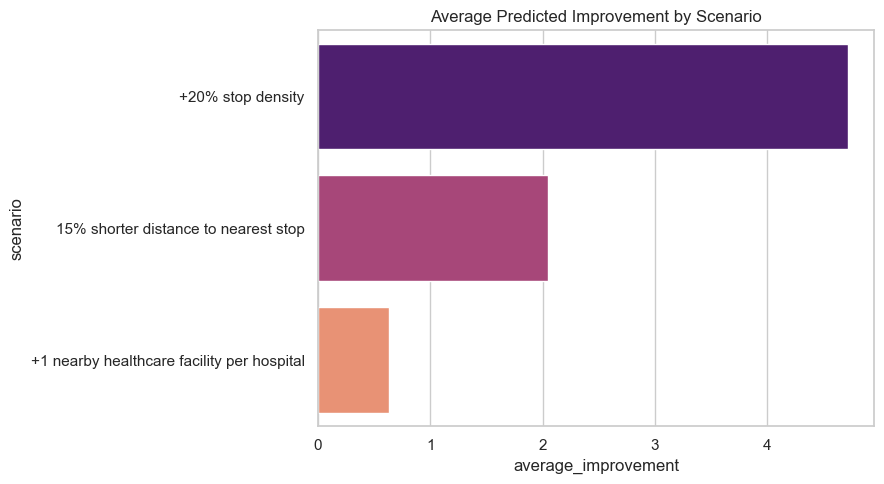

In [14]:
delta_cols = [c for c in scenario_compare.columns if c.startswith('delta_')]

avg_impacts = pd.DataFrame({
    'scenario': delta_cols,
    'average_improvement': [scenario_compare[c].mean() for c in delta_cols],
    'std_improvement': [scenario_compare[c].std() for c in delta_cols]
}).sort_values('average_improvement', ascending=False)

print('Average improvement by scenario:')
display(avg_impacts)

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_impacts, x='average_improvement', y='scenario', palette='magma')
plt.title('Average predicted improvement by intervention')
plt.tight_layout()
plt.show()

# Beneficiary analysis
best_scenario_col = avg_impacts.iloc[0]['scenario']
top_beneficiaries = scenario_compare.nlargest(10, best_scenario_col)[[DISTRICT_COL, 'urban_ring', 'baseline', best_scenario_col]]

# Remaining underserved after best scenario
if TARGET_COL == 'accessibility_score':
    remaining_underserved = scenario_compare.nsmallest(10, 'combined_transport_facility')
else:
    remaining_underserved = scenario_compare.nlargest(10, 'combined_transport_facility')

print('Top beneficiaries under the best scenario:')
display(top_beneficiaries)

print('Facilities that remain underserved after combined intervention:')
display(remaining_underserved[[DISTRICT_COL, 'urban_ring', 'combined_transport_facility']])


## 6. Geospatial Visualization of Predictions and Intervention Effects


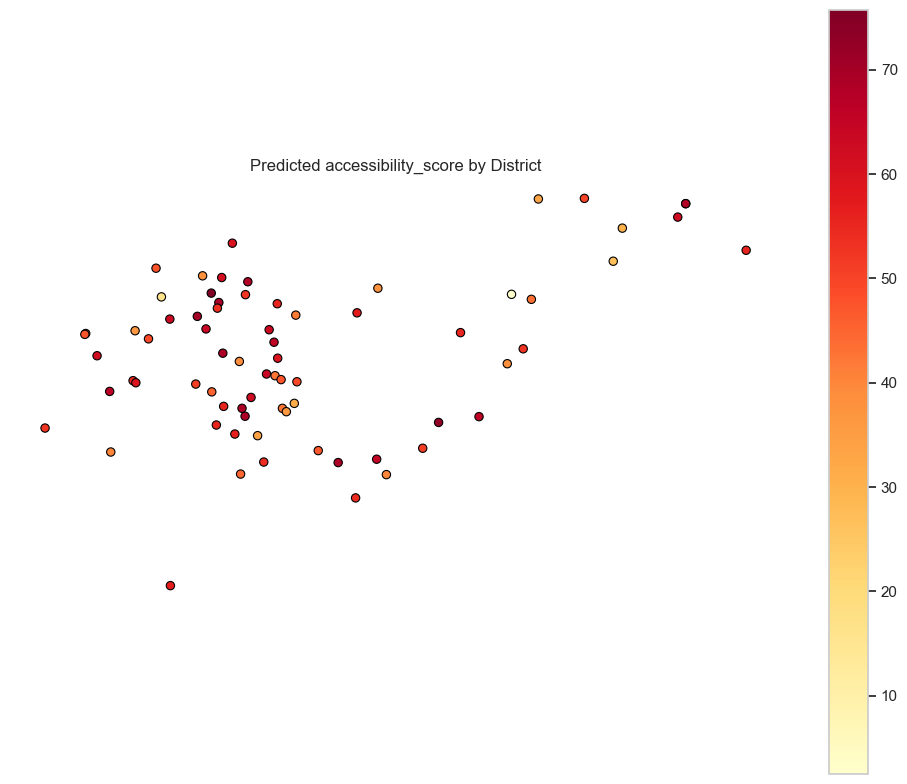

In [16]:
pred_map = model_df[[DISTRICT_COL, 'geometry']].copy()
pred_map = pred_map.merge(scenario_compare[[DISTRICT_COL, 'baseline', 'delta_transport_plus', 'delta_facility_plus', 'delta_combined_transport_facility']], on=DISTRICT_COL, how='left')
pred_map = gpd.GeoDataFrame(pred_map, geometry='geometry', crs=model_df.crs)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pred_map.plot(column='baseline', cmap='YlOrRd', legend=True, ax=axes[0])
axes[0].set_title(f'Baseline predicted {TARGET_COL} (facility level)')
axes[0].set_axis_off()

pred_map.plot(column='delta_combined_transport_facility', cmap='YlGnBu', legend=True, ax=axes[1])
axes[1].set_title('Predicted improvement from combined intervention')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## 7. Planning Prioritization and Recommendations

This section turns model outputs into action-oriented priorities for transport and healthcare planning.


In [17]:
priority_df = scenario_compare.merge(
    model_df[[DISTRICT_COL, 'population', 'stop_density', 'num_healthcare_facilities', 'urban_ring']],
    on=[DISTRICT_COL, 'urban_ring'],
    how='left'
)

# Vulnerability index (higher means more underserved)
if TARGET_COL == 'accessibility_score':
    priority_df['vulnerability_score'] = (
        (priority_df['baseline'].rank(pct=True, ascending=True) * 0.5) +
        (priority_df['stop_density'].rank(pct=True, ascending=True) * 0.2) +
        (priority_df['num_healthcare_facilities'].rank(pct=True, ascending=True) * 0.3)
    )
else:
    priority_df['vulnerability_score'] = (
        (priority_df['baseline'].rank(pct=True, ascending=False) * 0.5) +
        (priority_df['stop_density'].rank(pct=True, ascending=True) * 0.2) +
        (priority_df['num_healthcare_facilities'].rank(pct=True, ascending=True) * 0.3)
    )

priority_df['transport_gain'] = priority_df[['delta_transport_plus', 'delta_walkability_plus']].mean(axis=1)
priority_df['facility_gain'] = priority_df['delta_facility_plus']
priority_df['dominant_lever'] = np.where(
    priority_df['transport_gain'] >= priority_df['facility_gain'],
    'Transport-first',
    'Facility-first'
)
priority_df['combined_gain'] = priority_df['delta_combined_transport_facility']

# Facility-level ranking
facility_priority = priority_df.sort_values(
    ['vulnerability_score', 'combined_gain'], ascending=[False, False]
).reset_index(drop=True)
facility_priority['priority_rank'] = np.arange(1, len(facility_priority) + 1)

# District/area proxy ranking via urban rings
ring_priority = priority_df.groupby('urban_ring', as_index=False).agg(
    avg_vulnerability=('vulnerability_score', 'mean'),
    avg_combined_gain=('combined_gain', 'mean'),
    avg_transport_gain=('transport_gain', 'mean'),
    avg_facility_gain=('facility_gain', 'mean'),
    n_facilities=(DISTRICT_COL, 'count')
).sort_values('avg_vulnerability', ascending=False)

# Final recommendation table
recommendation_table = facility_priority[[
    'priority_rank', DISTRICT_COL, 'urban_ring', 'baseline', 'vulnerability_score',
    'transport_gain', 'facility_gain', 'combined_gain', 'dominant_lever'
]].copy()
recommendation_table['recommended_action'] = np.where(
    recommendation_table['dominant_lever'] == 'Transport-first',
    'Increase stop coverage + improve first-mile access',
    'Expand nearby facility capacity and service points'
)

print('Top 15 facility priorities:')
display(recommendation_table.head(15))

print('Urban-ring (district proxy) priorities:')
display(ring_priority)

print('Interpretation highlights:')
print('- Facilities with high vulnerability and high combined gain should be targeted first.')
print('- Dominant lever compares marginal effect of transport vs facility interventions.')
print('- Urban ring summary helps convert facility-level results into area-level planning.')


Most underserved hospitals (model-based):


,facility,baseline_pred,transport_pred,facilities_pred,network_pred,delta_transport,delta_facilities,delta_network,population,stop_density,num_healthcare_facilities
0,hôpital mohammed v,2.477716,3.196759,3.108219,8.730625,0.719044,0.630504,6.252909,463,1,1
1,clinique val d'anfa,16.246921,18.404052,16.877425,21.681473,2.157131,0.630504,5.434552,283,3,3
2,clinique adoha,27.318172,28.037215,27.948675,29.803755,0.719044,0.630504,2.485583,306,1,1
3,clinique firdaous,30.220376,31.658463,30.850880,32.914929,1.438087,0.630504,2.694553,615,2,1
4,clinique le parc,31.938005,34.095135,32.568508,35.255739,2.157131,0.630504,3.317734,302,3,6
5,clinique ain saba3,32.902689,35.778864,33.533193,35.921054,2.876174,0.630504,3.018365,359,4,0


Key drivers ranked by influence:


,feature,importance
3,stop_density,10.329896
5,distance_to_nearest_stop_m,8.356829
2,built_up_area,1.763897
4,num_healthcare_facilities,1.707197
1,population_density,0.959642
7,local_edge_count_500m,0.959642
0,population,0.959642
6,distance_to_nearest_node_m,0.461453


Most effective simulated intervention: +20% stop density | Avg effect = 4.71


### Suggested narrative for your report

- We predicted facility-level healthcare accessibility using transport supply, healthcare supply, and network-structure features.
- The final model was selected using cross-validated performance, then stress-tested with train/test diagnostics to check overfitting.
- Interpretation focused on transport versus healthcare-supply drivers, showing which levers most shape inequality.
- Scenario simulations compared transport-only, facility-only, and combined policies, revealing heterogeneous gains across facilities and urban rings.
- Priority tables convert model outputs into practical planning actions: where to intervene first and which type of intervention is likely to be more effective.
